# Are the Explanations Stable?

If two models that are equally accurate produce *different* heatmaps for the same scan, then any single published heatmap is an accident of training. We test two kinds of stability:

- **Seed stability.** Same architecture (ResNet18), three different training seeds, identical data. Do their heatmaps agree?
- **Architecture stability.** ResNet18 vs EfficientNet-B0, at comparable accuracy. Do *they* agree?

### How agreement is measured
For the same image, compare two heatmaps with:
- **SSIM** — structural similarity of the two maps (1 = identical, ~0 = unrelated).
- **Spearman** — rank correlation of pixel importances (1 = same ranking, 0 = none).

We also compute a **random-pair baseline** (two random maps) so you know what "no agreement" looks like on this scale.

### Why the accuracy match matters
Disagreement only means something if the models are equally good. We report each model's accuracy alongside, so a reviewer can't say "they differ because one is worse."

In [1]:
# Cell 1 — install + imports
!pip install grad-cam==1.5.4 timm --quiet

from pathlib import Path
import numpy as np, pandas as pd
import torch, torch.nn as nn, timm
from torch.utils.data import DataLoader, Dataset
from skimage.metrics import structural_similarity as ssim
from scipy.stats import spearmanr
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
if device == "cpu":
    print("WARNING: no GPU — slow. Turn on the T4.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 100.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
device: cuda


## Cell 2 — settings

`SEEDS` are the ResNet seeds you already trained in NB3b. `ARCH2` is the second architecture, trained here on the honest folds (seed 42) for the architecture comparison. `N_EVAL` images per fold keeps agreement computation quick.

In [2]:
# Cell 2
IN_DIR  = "/kaggle/input"
OUT_DIR = "/kaggle/working/stability"

ARCH1   = "resnet18"
ARCH2   = "efficientnet_b0"
SEEDS   = [42, 1, 2]          
FOLDS   = [0, 1, 2, 3, 4]
N_EVAL  = 40                  # images sampled per fold for agreement
EPOCHS  = 20                  # for training ARCH2
BATCH   = 32
LR      = 3e-4
SAMPLE_SEED = 0

In [3]:
# Cell 3 — locate inputs
def find(name):
    hits = list(Path(IN_DIR).rglob(name))
    assert hits, f"{name} not found under {IN_DIR}."
    return hits[0]

images   = np.load(find("images.npy"))
manifest = pd.read_csv(find("manifest_splits.csv"))
RESNET_DIR = find(f"model_{ARCH1}_seed{SEEDS[0]}_fold_honest_fold0.pt").parent
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)
print("images", images.shape, "| resnet models in", RESNET_DIR)

images (3064, 224, 224) | resnet models in /kaggle/input/notebooks/souravpaul100304/3b-multiseed/runs_multiseed


## Cell 4 — train EfficientNet-B0 (the second architecture)

Same training recipe as ResNet runs, on the honest folds only (that's all the architecture comparison needs). Seeded for reproducibility. Skips any fold already trained, so re-runs are cheap.

In [4]:
# Cell 4 — train ARCH2 on honest folds
IMAGENET_MEAN = np.array([0.485,0.456,0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229,0.224,0.225], dtype=np.float32)

class DS(Dataset):
    def __init__(self, imgs, labels, train=False):
        self.imgs, self.labels, self.train = imgs, labels, train
    def __len__(self): return len(self.labels)
    def __getitem__(self, i):
        img = self.imgs[i].astype(np.float32)/255.0
        if self.train and np.random.rand()<0.5: img = np.fliplr(img).copy()
        img = np.stack([img]*3,-1); img=(img-IMAGENET_MEAN)/IMAGENET_STD
        return torch.from_numpy(img.transpose(2,0,1)), int(self.labels[i])

def set_seed(s): np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)

def train_arch2(fold, seed=42):
    out = Path(OUT_DIR)/f"model_{ARCH2}_seed{seed}_fold_honest_fold{fold}.pt"
    if out.exists(): 
        print(f"  fold {fold}: already trained"); return
    set_seed(seed)
    labels = manifest["label"].values - 1
    tr = np.where((manifest.fold_honest!=fold).values)[0]
    te = np.where((manifest.fold_honest==fold).values)[0]
    g = torch.Generator(); g.manual_seed(seed)
    tr_dl = DataLoader(DS(images[tr], labels[tr], True), batch_size=BATCH, shuffle=True,
                       num_workers=2, generator=g)
    te_dl = DataLoader(DS(images[te], labels[te], False), batch_size=BATCH)
    model = timm.create_model(ARCH2, pretrained=True, num_classes=3).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    crit = nn.CrossEntropyLoss()
    for ep in range(EPOCHS):
        model.train()
        for x,y in tr_dl:
            x,y=x.to(device),y.to(device)
            opt.zero_grad(); crit(model(x),y).backward(); opt.step()
        sch.step()
    model.eval(); correct=tot=0
    with torch.no_grad():
        for x,y in te_dl:
            x,y=x.to(device),y.to(device)
            correct+=(model(x).argmax(1)==y).sum().item(); tot+=len(y)
    torch.save(model.state_dict(), out)
    print(f"  fold {fold}: acc {correct/tot:.4f}")

print(f"Training {ARCH2} on honest folds...")
for f in FOLDS: train_arch2(f)
print("done")

Training efficientnet_b0 on honest folds...


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

  fold 0: acc 0.9457
  fold 1: acc 0.8825
  fold 2: acc 0.9801
  fold 3: acc 0.9095
  fold 4: acc 0.9446
done


## Cell 5 — heatmap helpers (both architectures)

The CAM target layer differs by architecture. This picks the right one and returns a normalised 224×224 heatmap for any model.

In [5]:
# Cell 5 — CAM helpers
def prep(img_uint8):
    a = np.stack([img_uint8.astype(np.float32)/255.0]*3,-1)
    a = (a-IMAGENET_MEAN)/IMAGENET_STD
    return torch.from_numpy(a.transpose(2,0,1).astype(np.float32))

def target_layers(model, arch):
    if "resnet" in arch: return [model.layer4[-1]]
    if "efficientnet" in arch: return [model.conv_head]
    raise ValueError(f"no target layer rule for {arch}")

def load(arch, seed, fold, model_dir):
    m = timm.create_model(arch, pretrained=False, num_classes=3)
    m.load_state_dict(torch.load(model_dir/f"model_{arch}_seed{seed}_fold_honest_fold{fold}.pt",
                                 map_location=device))
    return m.to(device).eval()

def heatmap(model, arch, img_uint8):
    eng = GradCAM(model=model, target_layers=target_layers(model, arch))
    x = prep(img_uint8).unsqueeze(0).to(device)
    with torch.no_grad(): pred=int(model(x).argmax(1).item())
    return eng(input_tensor=x, targets=[ClassifierOutputTarget(pred)])[0]

def agree(a, b):
    s = ssim(a, b, data_range=1.0)
    r = spearmanr(a.flatten(), b.flatten()).correlation
    return float(s), float(r if r==r else 0.0)
print("helpers ready")

helpers ready


## Cell 6 — compute agreement

For each honest fold and each sampled image: compute heatmaps from the three ResNet seeds and from EfficientNet, then measure agreement for seed pairs, for the architecture pair, and for a random pair (baseline).

In [6]:
# Cell 6 — run
rng = np.random.default_rng(SAMPLE_SEED)
rows = []
for fold in FOLDS:
    resnets = {s: load(ARCH1, s, fold, RESNET_DIR) for s in SEEDS}
    eff = load(ARCH2, 42, fold, Path(OUT_DIR))
    test_idx = np.where((manifest.fold_honest==fold).values)[0]
    pick = rng.choice(test_idx, min(N_EVAL, len(test_idx)), replace=False)

    for i in pick:
        r_maps = {s: heatmap(resnets[s], ARCH1, images[i]) for s in SEEDS}
        e_map  = heatmap(eff, ARCH2, images[i])

        # seed pairs (same arch)
        pairs = [(SEEDS[a], SEEDS[b]) for a in range(len(SEEDS)) for b in range(a+1,len(SEEDS))]
        for s1,s2 in pairs:
            s,r = agree(r_maps[s1], r_maps[s2])
            rows.append({"fold":fold,"idx":int(i),"type":"seed","pair":f"{s1}-{s2}","ssim":s,"spearman":r})
        # architecture pair (ResNet seed42 vs EfficientNet)
        s,r = agree(r_maps[42], e_map)
        rows.append({"fold":fold,"idx":int(i),"type":"arch","pair":"rn18-effb0","ssim":s,"spearman":r})
        # random baseline
        s,r = agree(rng.random(e_map.shape), rng.random(e_map.shape))
        rows.append({"fold":fold,"idx":int(i),"type":"random","pair":"rand","ssim":s,"spearman":r})

    del resnets, eff; torch.cuda.empty_cache()
    print(f"fold {fold} done")

df = pd.DataFrame(rows)
df.to_csv(Path(OUT_DIR)/"stability.csv", index=False)
print("saved stability.csv,", len(df), "rows")

fold 0 done
fold 1 done
fold 2 done
fold 3 done
fold 4 done
saved stability.csv, 1000 rows


## Cell 7 — the result

Three levels of agreement. Read them against each other:
- **random** ≈ the floor (what "no agreement" looks like).
- **seed** — same architecture, different seeds. How reproducible is a heatmap across retrainings?
- **arch** — different architectures at matched accuracy. Usually the lowest of the two real rows.

If seed agreement is well below 1.0, a single published heatmap isn't reproducible even for the *same* model design.

In [7]:
# Cell 7 — summarise
summary = df.groupby("type")[["ssim","spearman"]].agg(["mean","std"]).round(4)
print("Agreement by comparison type:")
print(summary.to_string())

print("\nPer-fold SSIM (seed vs arch):")
print(df[df.type!="random"].pivot_table(index="fold", columns="type",
      values="ssim", aggfunc="mean").round(4).to_string())

Agreement by comparison type:
          ssim         spearman        
          mean     std     mean     std
type                                   
arch    0.4268  0.1633   0.4439  0.3886
random  0.0057  0.0047   0.0002  0.0048
seed    0.7424  0.1227   0.8530  0.1592

Per-fold SSIM (seed vs arch):
type    arch    seed
fold                
0     0.4312  0.7294
1     0.3781  0.7347
2     0.4518  0.7639
3     0.4621  0.7306
4     0.4107  0.7536


## Cell 8 — accuracy match check

Confirms ResNet and EfficientNet are at comparable accuracy, so any disagreement isn't just one model being worse. Pulls ResNet accuracy from NB3b results and reports EfficientNet from Cell 4.

In [8]:
# Cell 8 — accuracy context
try:
    rn = pd.read_csv(find("results_multiseed.csv"))
    rn_acc = rn[(rn.split=="fold_honest")].accuracy.mean()
    print(f"ResNet18 honest accuracy (mean): {rn_acc:.4f}")
except Exception as e:
    print("ResNet results not found:", e)
# EfficientNet accuracies were printed in Cell 4; re-evaluate quickly:
labels = manifest["label"].values - 1
accs=[]
for fold in FOLDS:
    m = load(ARCH2, 42, fold, Path(OUT_DIR))
    te = np.where((manifest.fold_honest==fold).values)[0]
    correct=0
    with torch.no_grad():
        for i in te:
            x=prep(images[i]).unsqueeze(0).to(device)
            correct += int(m(x).argmax(1).item()==labels[i])
    accs.append(correct/len(te))
print(f"EfficientNet-B0 honest accuracy (mean): {np.mean(accs):.4f}")
print("If these are close, the architecture comparison is at matched accuracy.")

ResNet18 honest accuracy (mean): 0.9398
EfficientNet-B0 honest accuracy (mean): 0.9325
If these are close, the architecture comparison is at matched accuracy.


## Cell 9 — visual

Same scan, four heatmaps: ResNet seeds 42/1/2 and EfficientNet. If they visibly disagree, this single panel makes the stability point better than any table.

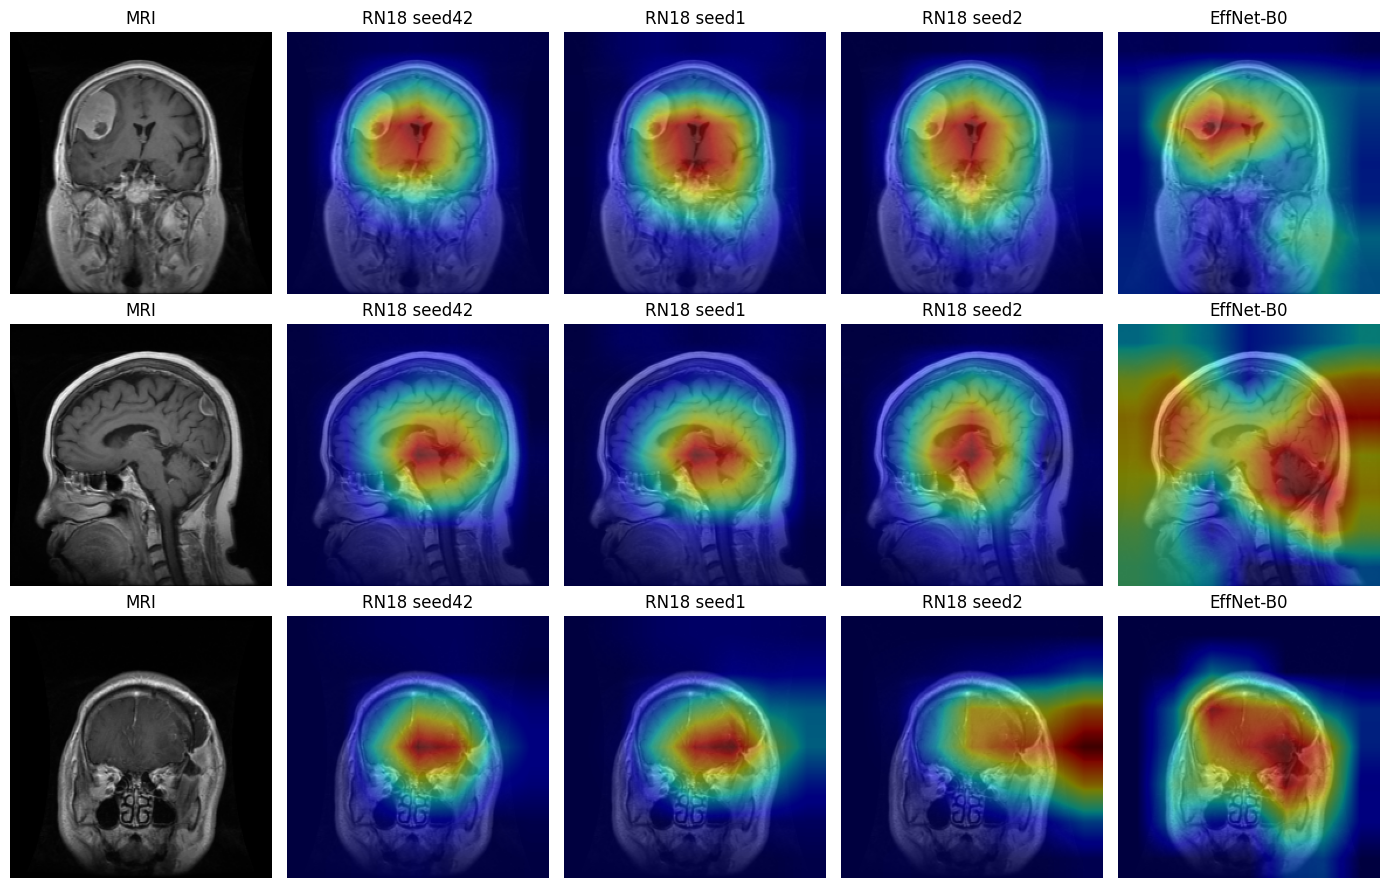

In [9]:
# Cell 9 — visual
import matplotlib.pyplot as plt
fold = 0
resnets = {s: load(ARCH1, s, fold, RESNET_DIR) for s in SEEDS}
eff = load(ARCH2, 42, fold, Path(OUT_DIR))
test_idx = np.where((manifest.fold_honest==fold).values)[0]
show = np.random.default_rng(3).choice(test_idx, 3, replace=False)

fig, axes = plt.subplots(len(show), 5, figsize=(14, 3*len(show)))
for r,i in enumerate(show):
    axes[r,0].imshow(images[i], cmap="gray"); axes[r,0].set_title("MRI"); axes[r,0].axis("off")
    for c,s in enumerate(SEEDS):
        hm = heatmap(resnets[s], ARCH1, images[i])
        axes[r,c+1].imshow(images[i], cmap="gray"); axes[r,c+1].imshow(hm, cmap="jet", alpha=.5)
        axes[r,c+1].set_title(f"RN18 seed{s}"); axes[r,c+1].axis("off")
    hm = heatmap(eff, ARCH2, images[i])
    axes[r,4].imshow(images[i], cmap="gray"); axes[r,4].imshow(hm, cmap="jet", alpha=.5)
    axes[r,4].set_title("EffNet-B0"); axes[r,4].axis("off")
plt.tight_layout(); plt.savefig(Path(OUT_DIR)/"stability_panel.png", dpi=130); plt.show()